# Distribution du nombre de tokens des CVs

Ce notebook calcule le nombre de tokens (tokenizer BERT `ml6team/keyphrase-extraction-kbir-inspec`) de tous les CVs du dossier `DEFAULT_CV_CATEGORY`, affiche les statistiques (moyenne, écart type, min, max) et trace la distribution.

In [1]:
import statistics


import matplotlib.pyplot as plt
from transformers import AutoTokenizer

from ats_system.config import CV_DIR, DEFAULT_CV_CATEGORY
from ats_system.data import import_pdf

MODEL_NAME = "ml6team/keyphrase-extraction-kbir-inspec"
BERT_MAX_TOKENS = 512
CATEGORY_DIR = CV_DIR / DEFAULT_CV_CATEGORY
CATEGORY_DIR

c:\Users\Antoine\Documents\prog\python\ats-system\ats_syst\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WindowsPath('C:/Users/Antoine/Documents/prog/python/ats-system/data/cv/ENGINEERING')

In [2]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

cv_files = sorted(CATEGORY_DIR.glob("*.pdf"))

token_counts = []
for i, cv_path in enumerate(cv_files, 1):
    cv = import_pdf(str(cv_path))
    n_tokens = len(tokenizer.encode(cv["content"], add_special_tokens=False))
    token_counts.append(n_tokens)
    print(f"{i}/{len(cv_files)} : {cv['id']} ({n_tokens} tokens)")

print(f"\n{len(token_counts)} CVs traités.")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (677 > 512). Running this sequence through the model will result in indexing errors


1/118 : 10030015.pdf (677 tokens)
2/118 : 10219099.pdf (1764 tokens)
3/118 : 10624813.pdf (1792 tokens)
4/118 : 10712803.pdf (2092 tokens)
5/118 : 10985403.pdf (1101 tokens)
6/118 : 11890896.pdf (1315 tokens)
7/118 : 11981094.pdf (1412 tokens)
8/118 : 12011623.pdf (1408 tokens)
9/118 : 12022566.pdf (1208 tokens)
10/118 : 12472574.pdf (3671 tokens)
11/118 : 12488356.pdf (1482 tokens)
12/118 : 12518008.pdf (1530 tokens)
13/118 : 12748557.pdf (1415 tokens)
14/118 : 13149176.pdf (1533 tokens)
15/118 : 13264796.pdf (4322 tokens)
16/118 : 14049846.pdf (1149 tokens)
17/118 : 14206561.pdf (726 tokens)
18/118 : 14554542.pdf (2707 tokens)
19/118 : 15139979.pdf (2990 tokens)
20/118 : 15601399.pdf (531 tokens)
21/118 : 15858254.pdf (1110 tokens)
22/118 : 15941675.pdf (1118 tokens)
23/118 : 16803215.pdf (1264 tokens)
24/118 : 16911115.pdf (1055 tokens)
25/118 : 17043822.pdf (1435 tokens)
26/118 : 17103000.pdf (1102 tokens)
27/118 : 17108676.pdf (1173 tokens)
28/118 : 17488801.pdf (966 tokens)
29/11

In [5]:
mean = statistics.mean(token_counts)
stdev = statistics.stdev(token_counts) if len(token_counts) > 1 else 0.0
median = statistics.median(token_counts)
total = sum(token_counts)

print(f"Dossier    : {CATEGORY_DIR}")
print(f"CVs        : {len(token_counts)}")
print(f"Total      : {total}")
print(f"Min        : {min(token_counts)}")
print(f"Max        : {max(token_counts)}")
print(f"Moyenne    : {mean:.1f}")
print(f"Médiane    : {median:.1f}")
print(f"Écart type : {stdev:.1f}")

Dossier    : C:\Users\Antoine\Documents\prog\python\ats-system\data\cv\ENGINEERING
CVs        : 118
Total      : 167778
Min        : 365
Max        : 4322
Moyenne    : 1421.8
Médiane    : 1346.5
Écart type : 586.9


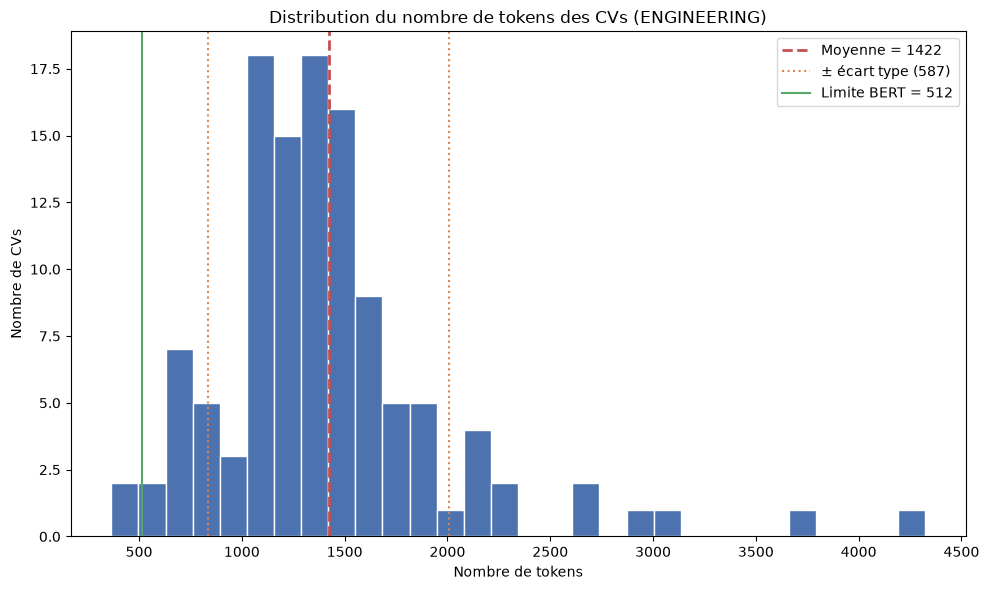

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(token_counts, bins=30, color="#4c72b0", edgecolor="white")

ax.axvline(mean, color="#c44e52", linestyle="--", linewidth=2, label=f"Moyenne = {mean:.0f}")
ax.axvline(mean - stdev, color="#dd8452", linestyle=":", linewidth=1.5, label=f"± écart type ({stdev:.0f})")
ax.axvline(mean + stdev, color="#dd8452", linestyle=":", linewidth=1.5)
ax.axvline(BERT_MAX_TOKENS, color="#55a868", linestyle="-", linewidth=1.5, label=f"Limite BERT = {BERT_MAX_TOKENS}")

ax.set_title(f"Distribution du nombre de tokens des CVs ({DEFAULT_CV_CATEGORY})")
ax.set_xlabel("Nombre de tokens")
ax.set_ylabel("Nombre de CVs")
ax.legend()

plt.tight_layout()
plt.show()